# Library Call Characterization in GPU-Accelerated HPC

Pooled analysis of compute-library calls across multiple application traces.
All metrics use **exclusive attribution** to avoid double-counting hierarchical calls.
Idle time (MPI synchronization, HPL/HPLMXP orchestration) is excluded entirely — it is
a measurement artifact of the per-call sync insertion methodology.

In [21]:
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import seaborn as sns
import arkouda as ak
from ampere import Ensemble, MetricConfig, MetricType, connect

plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})
BG = '#fafafa'

connect(server="localhost", port=5555)

/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/arkouda/core/client.py:860: RuntimeWarning: Version mismatch between client (2026.02.02+40.gec39a6ec8) and server (2026.02.02.1); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.
  warnings.warn(
connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [22]:
# -- Load all traces and pool them --

configs = {
    re.compile(r".*energy_count.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def topo_resolver(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

devices = [
    "A2rocm_smi:::energy_count:device=0",
    "A2rocm_smi:::energy_count:device=2",
    "A2rocm_smi:::energy_count:device=4",
    "A2rocm_smi:::energy_count:device=6",
]

ranks = [f"MPI Rank {i}" for i in range(8)]
node_ranks = {"Node0": ranks}

TRACES = {
    'HPL':     './hpl-captured-params',
    'HPL-MxP': './hpl-mxp',
    'HPG-MxP': './hpg-mxp-2'
}

energy_parts, power_parts = [], []
for label, path in TRACES.items():
    print(f"Loading {label} ...")
    ens = Ensemble.from_trace_paths([path], node_ranks, configs)

    joules = ak.DataFrame.concat([
        ens.attribute(m, topology_resolver=topo_resolver, strategy='exclusive')
        for m in devices
    ]).to_pandas()

    watts = ak.DataFrame.concat([
        ens.attribute(m, topology_resolver=topo_resolver, strategy='exclusive', output_mode='rate')
        for m in devices
    ]).to_pandas()

    joules['Duration'] = joules['End Time'] - joules['Start Time']
    watts['Duration']  = watts['End Time']  - watts['Start Time']

    energy_parts.append(joules)
    power_parts.append(watts)

energy_all = pd.concat(energy_parts, ignore_index=True)
power_all  = pd.concat(power_parts, ignore_index=True)
print(f"Total attributed rows: {len(energy_all):,}")

Loading HPL ...


Loading Runs: 100%|██████████| 1/1 [00:19<00:00, 19.85s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:03<00:00,  3.87s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=4' on Arkouda Server...


100%|██████████| 1/1 [00:07<00:00,  7.51s/it]


Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


100%|██████████| 1/1 [00:07<00:00,  7.75s/it]


This will transfer 1 GB from arkouda to pandas.Total attributed rows: 24,571,301


In [23]:
# -- Classify and keep only compute-library calls --

def classify(name):
    n = name.lower()
    if n.startswith('mpi_'):           return '_idle'
    if n.startswith('rocsolver'):      return 'rocSOLVER'
    if n.startswith('rocblas'):        return 'rocBLAS'
    if (n.startswith('hip') or 'devicemalloc' in n
        or 'hostmalloc' in n):         return 'HIP Runtime'
    if n.startswith('hpl_') or n.startswith('hplmxp') or n == 'main':
        return '_idle'
    return 'Other'

def short_name(name):
    paren = name.find('(')
    base = name[:paren] if paren != -1 else name
    angle = base.find('<')
    if angle != -1:
        base = base[:angle]
    return base.strip()

for df in (energy_all, power_all):
    df['Library']   = df['Name'].apply(classify)
    df['ShortName'] = df['Name'].apply(short_name)

energy = energy_all[energy_all['Library'] != '_idle'].copy()
power  = power_all[power_all['Library']  != '_idle'].copy()

MIN_DUR = 1e-3
energy_sig = energy[energy['Duration'] >= MIN_DUR].copy()
power_sig  = power[power['Duration']   >= MIN_DUR].copy()

PALETTE = {
    'rocBLAS':     '#2d6a4f',
    'rocSOLVER':   '#e07a3a',
    'HIP Runtime': '#9b5de5',
    'Other':       '#457b9d',
}
LIB_ORDER = ['rocBLAS', 'rocSOLVER', 'HIP Runtime', 'Other']
libs_present = [c for c in LIB_ORDER if c in energy['Library'].unique()]

print(f"Compute-library calls: {len(energy):,}  (significant: {len(energy_sig):,})")
print(f"\nEnergy by library (J):")
print(energy.groupby('Library')['Value'].sum().sort_values(ascending=False).to_string())

Compute-library calls: 17,638,570  (significant: 158,396)

Energy by library (J):
Library
rocBLAS        149938.447870
Other           46435.668636
rocSOLVER          45.404516
HIP Runtime         1.579618


## Figure 1 — Energy Share by Library

A single donut showing the fraction of total GPU energy consumed by each compute library,
pooled across all traces.

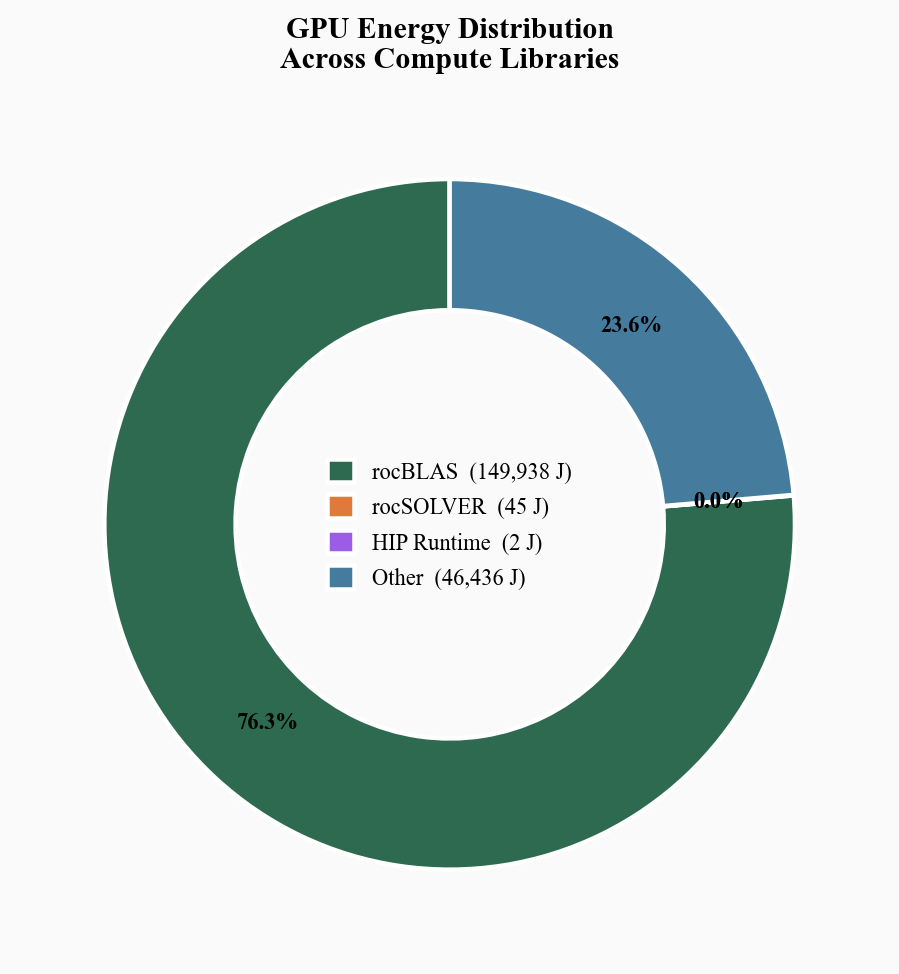

In [24]:
# -- Fig 1: Donut -- overall energy share --

lib_energy = energy.groupby('Library')['Value'].sum()
lib_energy = lib_energy.reindex([c for c in LIB_ORDER if c in lib_energy.index])

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor=BG)
ax.set_facecolor(BG)

colors = [PALETTE[c] for c in lib_energy.index]
wedges, texts, autotexts = ax.pie(
    lib_energy.values, labels=None, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.38, edgecolor='white', linewidth=1.8))
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

# Labels with energy totals
legend_labels = [f"{lib}  ({lib_energy[lib]:,.0f} J)" for lib in lib_energy.index]
ax.legend(wedges, legend_labels, loc='center', fontsize=9,
          frameon=False, handlelength=1.2, handleheight=1.2)
ax.set_title('GPU Energy Distribution\nAcross Compute Libraries', fontsize=12,
             fontweight='bold', pad=10)

fig.tight_layout()
fig.savefig('gen_fig1_energy_donut.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 2 — Per-Call Energy Distribution

Violin plots with embedded box plots showing how per-call energy varies within each library.
Only significant calls (>1 ms) are shown.

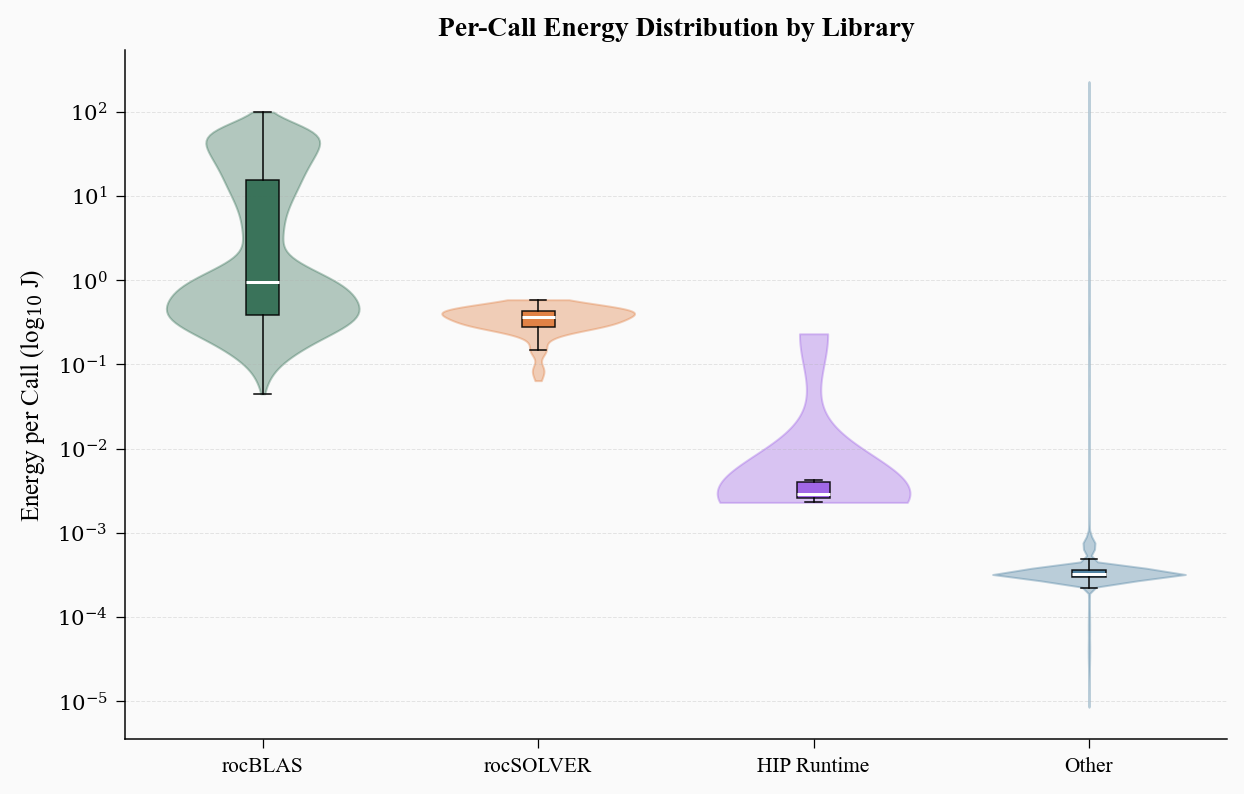

In [25]:
# -- Fig 2: Violin+box -- per-call energy by library --

plot_df = energy_sig[energy_sig['Value'] > 0].copy()
plot_df['log_energy'] = np.log10(plot_df['Value'])

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=BG)
ax.set_facecolor(BG)

positions = range(len(libs_present))
for i, lib in enumerate(libs_present):
    vals = plot_df[plot_df['Library'] == lib]['log_energy'].values
    if len(vals) < 5:
        continue
    vp = ax.violinplot(vals, positions=[i], showextrema=False, widths=0.7)
    for body in vp['bodies']:
        body.set_facecolor(PALETTE[lib])
        body.set_alpha(0.35)
        body.set_edgecolor(PALETTE[lib])
        body.set_linewidth(0.8)
    bp = ax.boxplot(vals, positions=[i], widths=0.12, patch_artist=True,
                    showfliers=False, zorder=3)
    bp['boxes'][0].set_facecolor(PALETTE[lib])
    bp['boxes'][0].set_edgecolor('black')
    bp['boxes'][0].set_linewidth(0.6)
    bp['boxes'][0].set_alpha(0.9)
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color('black')
            line.set_linewidth(0.6)
    bp['medians'][0].set_color('white')
    bp['medians'][0].set_linewidth(1.2)

ax.set_xticks(list(positions))
ax.set_xticklabels(libs_present)
ax.set_ylabel('Energy per Call (log$_{10}$ J)')
ax.set_title('Per-Call Energy Distribution by Library', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'$10^{{{int(x)}}}$' if x == int(x) else f'$10^{{{x:.1f}}}$'))
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig2_energy_violin.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 3 — Power ECDF by Library

Empirical cumulative distribution of instantaneous power draw,
showing how power is distributed across calls for each library.

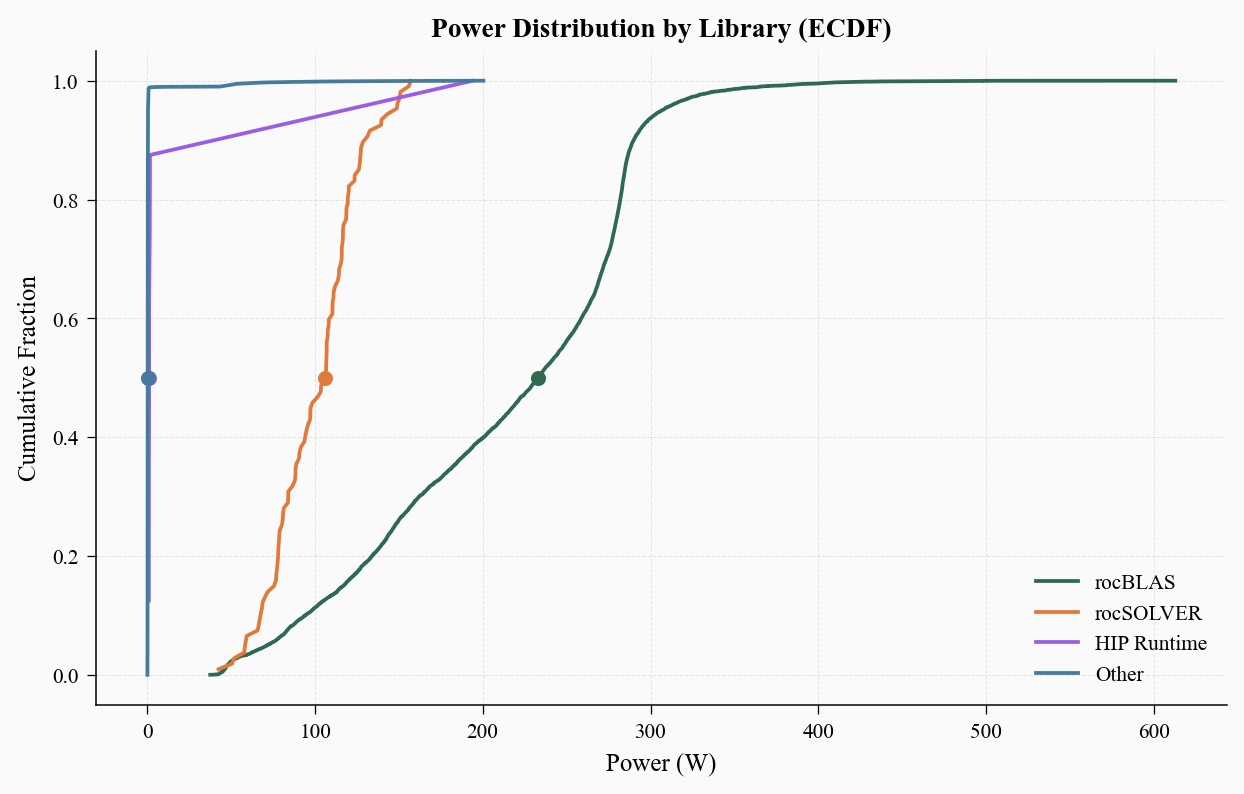

In [26]:
# -- Fig 3: ECDF of power by library --

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=BG)
ax.set_facecolor(BG)

for lib in libs_present:
    vals = np.sort(power_sig[power_sig['Library'] == lib]['Value'].dropna().values)
    if len(vals) == 0:
        continue
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, color=PALETTE[lib], linewidth=1.5, label=lib)
    # Mark median
    med = np.median(vals)
    ax.plot(med, 0.5, 'o', color=PALETTE[lib], markersize=5, zorder=5)

ax.set_xlabel('Power (W)')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('Power Distribution by Library (ECDF)', fontweight='bold')
ax.legend(frameon=False)
ax.grid(alpha=0.3, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig3_power_ecdf.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 4 — Energy vs. Duration

Each point is a single library call. The slope from the origin represents power.
Constant-power reference lines show where calls of different power levels fall.

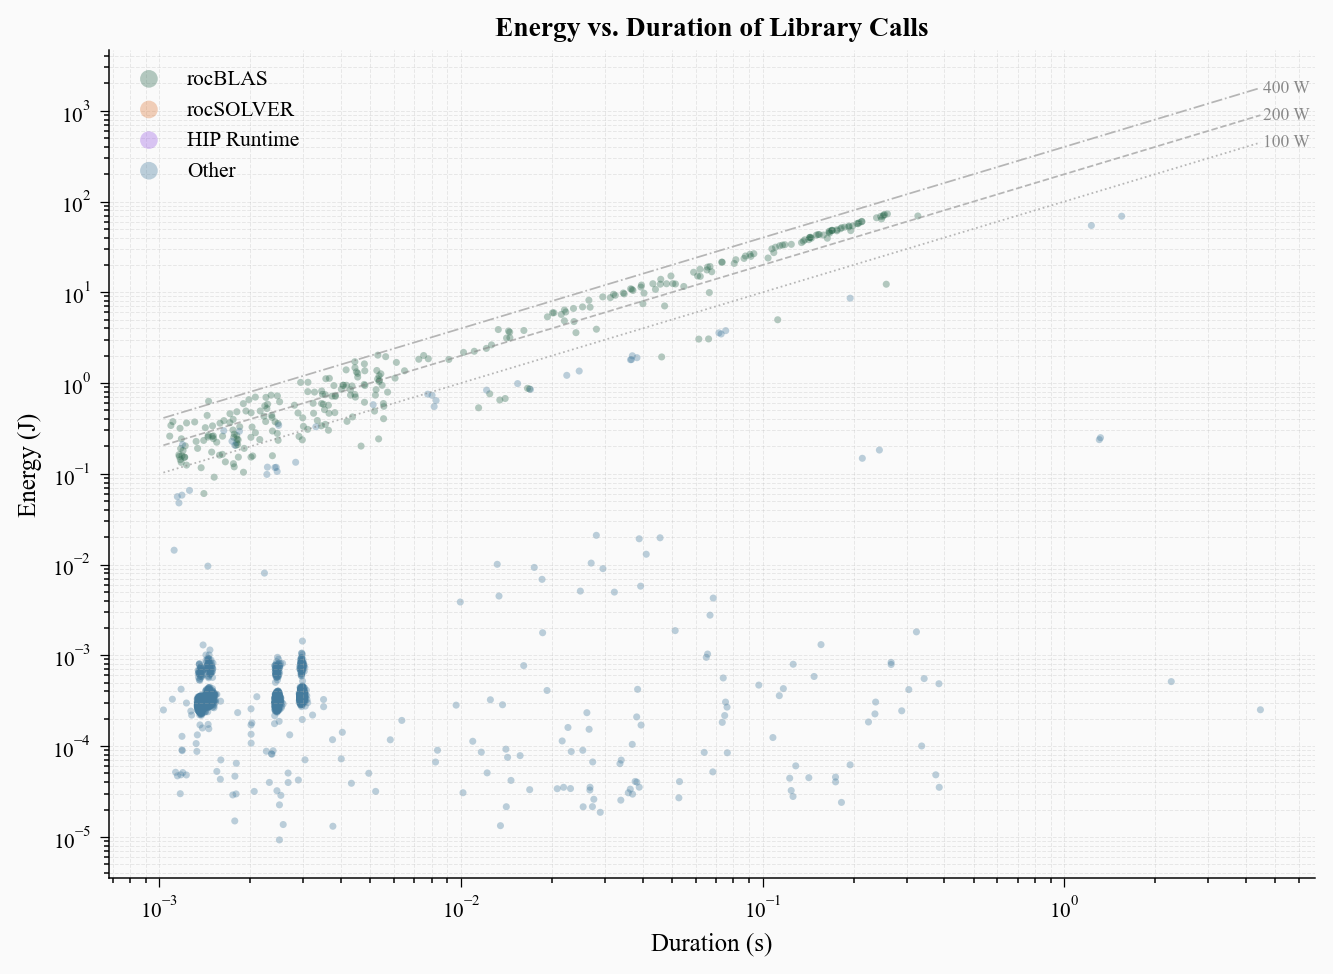

In [27]:
# -- Fig 4: Energy vs Duration scatter with power iso-lines --

sig = energy_sig[(energy_sig['Value'] > 0) & (energy_sig['Duration'] > 0)].copy()
MAX_PTS = 4000
if len(sig) > MAX_PTS:
    sig_plot = sig.sample(MAX_PTS, random_state=42)
else:
    sig_plot = sig

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=BG)
ax.set_facecolor(BG)

for lib in libs_present:
    sub = sig_plot[sig_plot['Library'] == lib]
    ax.scatter(sub['Duration'], sub['Value'],
               c=PALETTE[lib], s=8, alpha=0.35, label=lib, edgecolors='none')

# Constant-power reference lines
dur_range = np.array([sig_plot['Duration'].min(), sig_plot['Duration'].max()])
for pw, ls in [(100, ':'), (200, '--'), (400, '-.')]:
    ax.plot(dur_range, dur_range * pw, color='#888888', linewidth=0.7,
            linestyle=ls, alpha=0.6, zorder=1)
    ax.text(dur_range[-1] * 1.02, dur_range[-1] * pw,
            f'{pw} W', fontsize=7, color='#888888', va='center')

ax.set_xlabel('Duration (s)')
ax.set_ylabel('Energy (J)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Energy vs. Duration of Library Calls', fontweight='bold')
ax.legend(frameon=False, markerscale=2.5, fontsize=8.5)
ax.grid(alpha=0.25, linestyle='--', which='both')

fig.tight_layout()
fig.savefig('gen_fig4_energy_vs_duration.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 4b — Energy vs. Power (Function-Level Bubbles)

Each bubble is one function aggregated across all traces. X shows mean power draw,
Y shows mean energy per call, and bubble size encodes total energy contribution.


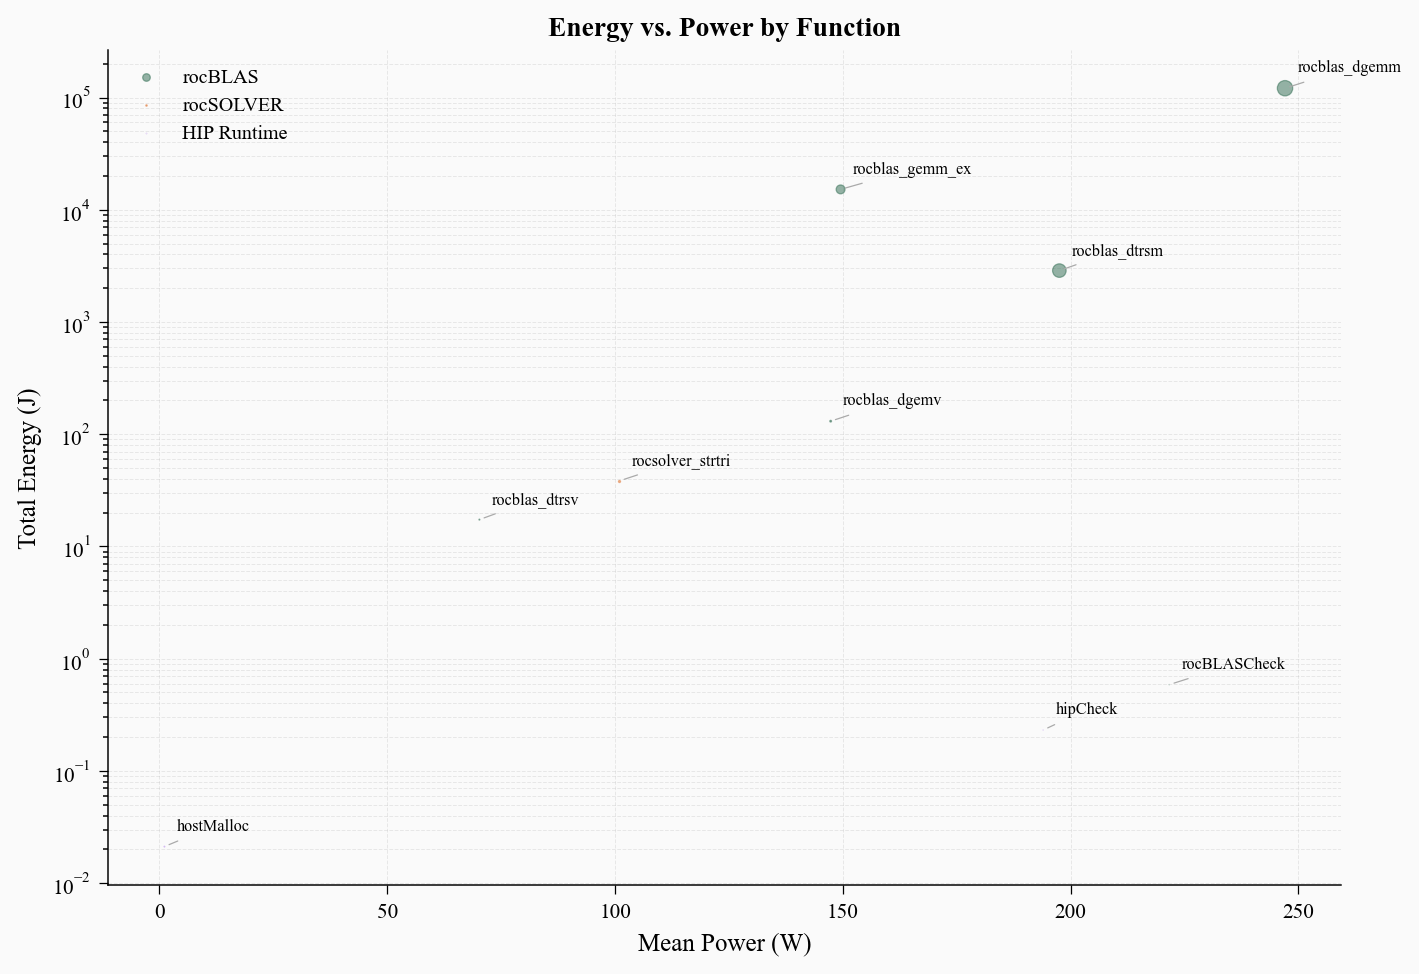

In [49]:
# -- Fig 4b: Energy vs Power bubble (per function) --

sig = energy_sig[(energy_sig['Value'] > 0) & (energy_sig['Duration'] > 0)].copy()
sig['Power'] = sig['Value'] / sig['Duration']

func_stats = (sig.groupby(['ShortName', 'Library'])
              .agg(total_energy=('Value', 'sum'),
                   mean_energy=('Value', 'mean'),
                   mean_power=('Power', 'mean'),
                   count=('Value', 'size'))
              .reset_index())

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG)
ax.set_facecolor(BG)

size_scale = 800 / func_stats['total_energy'].max()
for lib in libs_present:
    if lib == 'Other': continue
    sub = func_stats[func_stats['Library'] == lib]
    ax.scatter(sub['mean_power'], sub['total_energy'],
               s=sub['count'] * size_scale,
               c=PALETTE[lib], alpha=0.5, edgecolors=PALETTE[lib],
               linewidth=0.5, label=lib, zorder=3)

# Label the top-5 by total energy
top5 = func_stats[func_stats['Library'] != 'Other']
# top5 = top5.nlargest(5, 'total_energy')

for _, row in top5.iterrows():
    ax.annotate(row['ShortName'], (row['mean_power'], row['total_energy']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

# ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mean Power (W)')
ax.set_ylabel('Total Energy (J)')
ax.set_title('Energy vs. Power by Function', fontweight='bold')
ax.legend(frameon=False, markerscale=0.7, fontsize=8)
ax.grid(alpha=0.25, linestyle='--', which='both')

fig.tight_layout()
fig.savefig('gen_fig4b_energy_vs_power.pdf', facecolor=BG, bbox_inches='tight')
plt.show()


## Figure 5 — Top 20 Functions by Total Energy

Horizontal bar chart ranking the highest energy-consuming functions across all traces.
Color indicates the parent library.

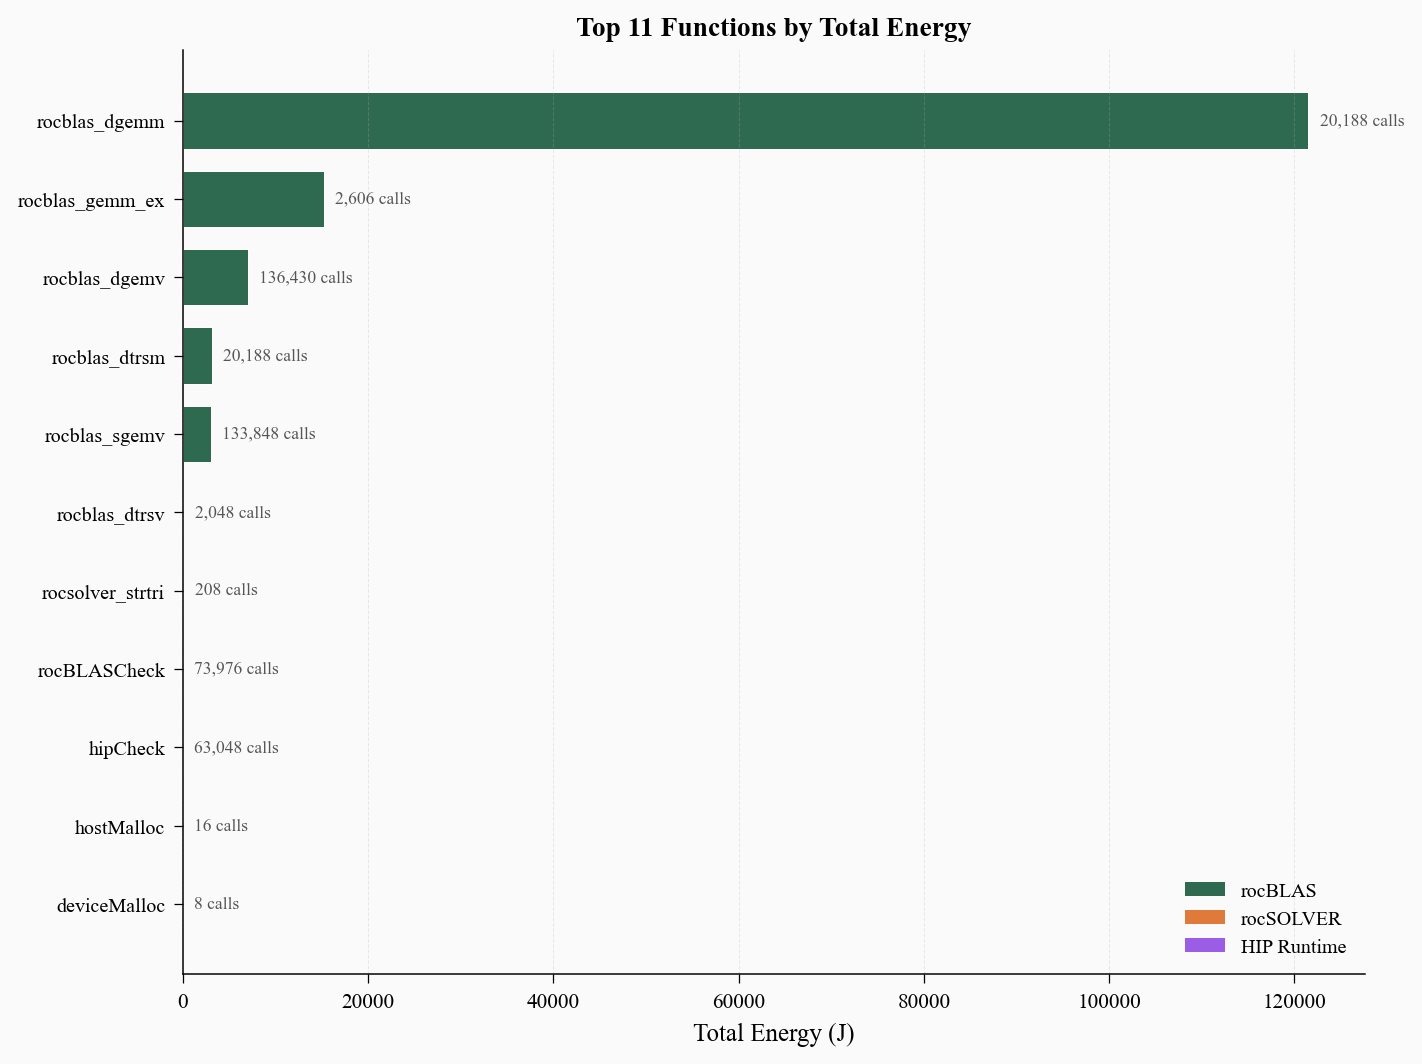

In [29]:
# Obtenemos la cantidad real de filas que nos quedaron después de filtrar
actual_n = len(func_energy)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

colors = [PALETTE.get(row['Library'], '#999999') for _, row in func_energy.iterrows()]

# Cambiamos range(TOP_N) por range(actual_n)
bars = ax.barh(range(actual_n), func_energy['total_energy'].values,
               color=colors, edgecolor='white', linewidth=0.4, height=0.72)

# También ajustamos los ticks del eje Y para que coincidan
ax.set_yticks(range(actual_n))
ax.set_yticklabels(func_energy['ShortName'].values, fontsize=8)

ax.invert_yaxis()
ax.set_xlabel('Total Energy (J)')
# Actualizamos el título por si quedan menos de 20
ax.set_title(f'Top {actual_n} Functions by Total Energy', fontweight='bold')

# Annotate counts
for i, (_, row) in enumerate(func_energy.iterrows()):
    ax.text(row['total_energy'] + func_energy['total_energy'].max() * 0.01, i,
            f"{row['count']:,} calls", va='center', fontsize=7, color='#555555')

# Library legend
handles = [mpatches.Patch(facecolor=PALETTE[c], label=c) for c in libs_present
           if c in func_energy['Library'].values]
ax.legend(handles=handles, frameon=False, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.25, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig5_top_functions.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 6 — Call Frequency vs. Energy per Call

Each bubble is one function. The x-axis shows how often it is called,
the y-axis shows its average energy per call, and bubble size encodes total energy.
Functions in the upper-right are both frequent and expensive.

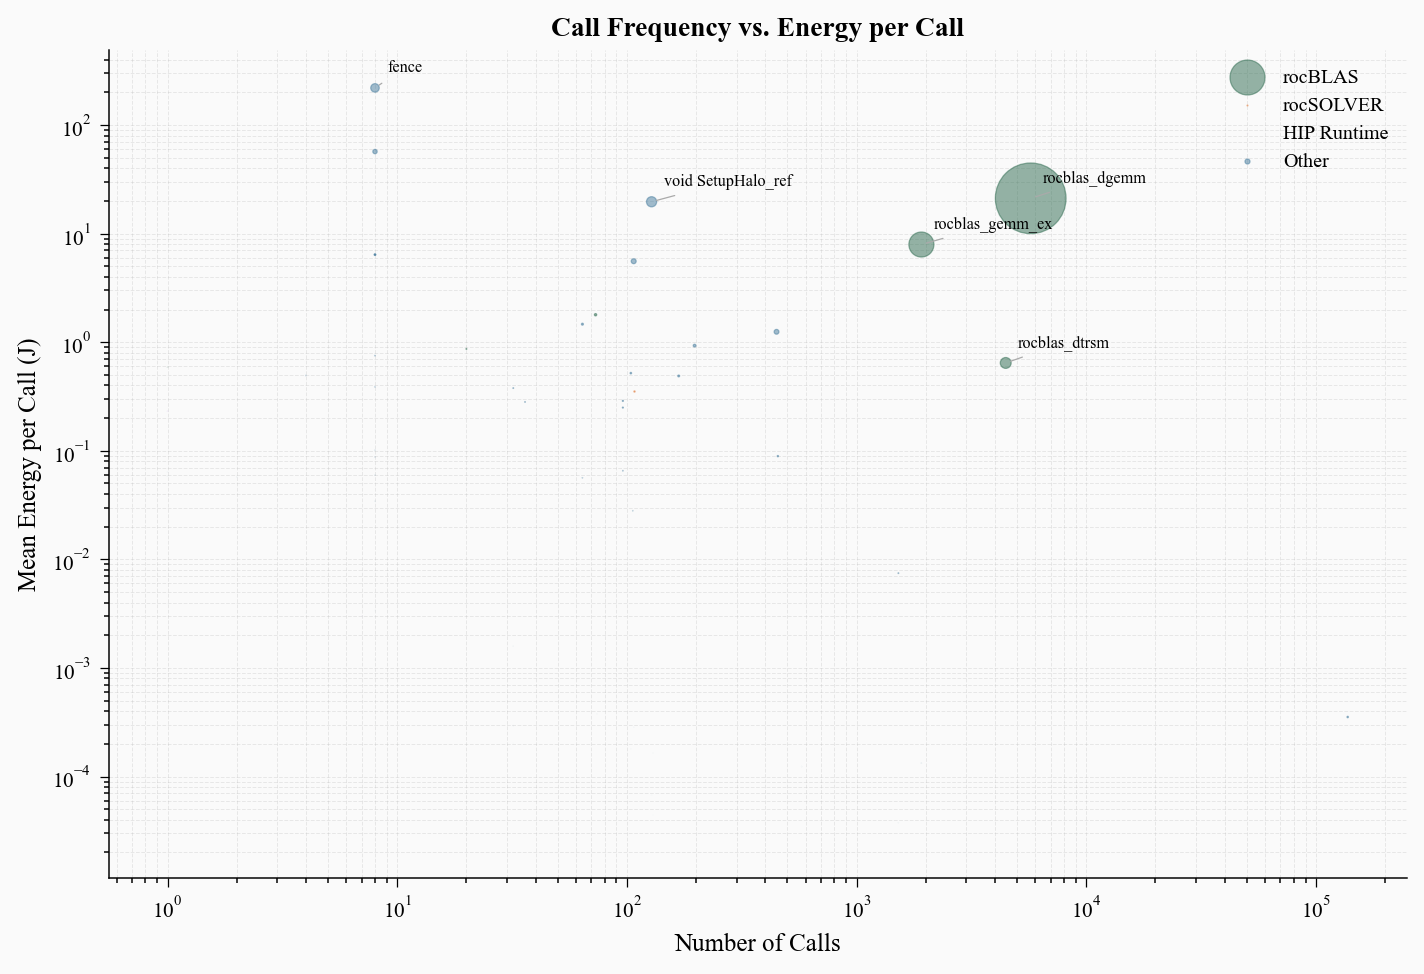

In [30]:
# -- Fig 6: Frequency vs energy-per-call bubble --

func_stats = (energy_sig[energy_sig['Value'] > 0]
              .groupby(['ShortName', 'Library'])
              .agg(total_energy=('Value', 'sum'),
                   mean_energy=('Value', 'mean'),
                   count=('Value', 'size'))
              .reset_index())

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG)
ax.set_facecolor(BG)

size_scale = 800 / func_stats['total_energy'].max()
for lib in libs_present:
    sub = func_stats[func_stats['Library'] == lib]
    ax.scatter(sub['count'], sub['mean_energy'],
               s=sub['total_energy'] * size_scale,
               c=PALETTE[lib], alpha=0.5, edgecolors=PALETTE[lib],
               linewidth=0.5, label=lib, zorder=3)

# Label the top-5 by total energy
top5 = func_stats.nlargest(5, 'total_energy')
for _, row in top5.iterrows():
    ax.annotate(row['ShortName'], (row['count'], row['mean_energy']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Calls')
ax.set_ylabel('Mean Energy per Call (J)')
ax.set_title('Call Frequency vs. Energy per Call', fontweight='bold')
ax.legend(frameon=False, markerscale=0.7, fontsize=8)
ax.grid(alpha=0.25, linestyle='--', which='both')

fig.tight_layout()
fig.savefig('gen_fig6_freq_vs_energy.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 7 — Ridgeline: Call Duration Distributions

KDE ridgeline plot showing how call durations are distributed for the most
energy-intensive functions. Longer tails indicate high-variance workloads.

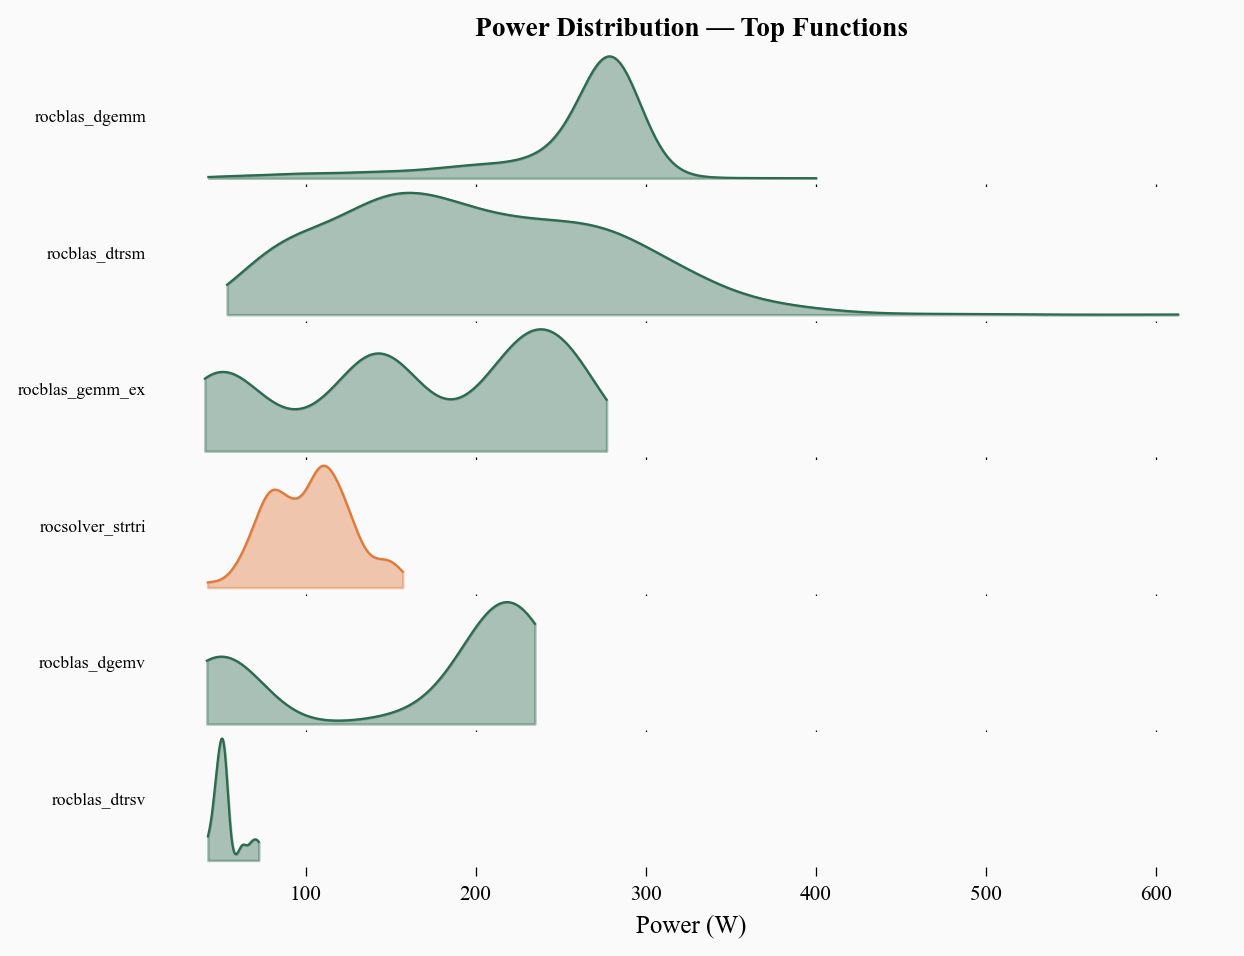

In [31]:
# -- Fig 7: Ridgeline (Cleaned and Filtered) --

# 1. Filter out 'Other' library and durations less than 2ms (0.002s)
power_filtered = power_sig[
    (power_sig['Library'] != 'Other') & 
    (power_sig['Library'] != 'HIP Runtime') & 
    (power_sig['Duration'] >= 0.0025)
].copy()

# 2. Identify top functions by total power value
potential_top = (power_filtered[power_filtered['Value'] > 0]
                 .groupby('ShortName')['Value'].sum()
                 .sort_values(ascending=False).head(10).index.tolist())

# 3. Pre-filter: Keep only functions with enough data points for KDE
final_ordered = []
for func in potential_top:
    vals = power_filtered[power_filtered['ShortName'] == func]['Value'].values
    if len(vals) >= 3: # Minimum threshold for KDE stability
        final_ordered.append(func)

# 4. Prepare plotting dataframe
ridge_df = power_filtered[power_filtered['ShortName'].isin(final_ordered)].copy()

# 5. Create figure with dynamic sizing based on actual function count
if not final_ordered:
    print("Not enough data points found after filtering to generate plot.")
else:
    fig, axes = plt.subplots(len(final_ordered), 1, 
                              figsize=(7, 0.9 * len(final_ordered)),
                              sharex=True, facecolor=BG)
    
    # Handle case where only 1 function remains
    if len(final_ordered) == 1:
        axes = [axes]

    for i, func in enumerate(final_ordered):
        ax = axes[i]
        ax.set_facecolor(BG)
        
        subset = ridge_df[ridge_df['ShortName'] == func]
        vals = subset['Value'].values
        lib = subset['Library'].iloc[0]

        try:
            kde = gaussian_kde(vals, bw_method=0.3)
            # Create a smooth X range for the density plot
            x_range = np.linspace(vals.min(), vals.max(), 300)
            y_dens = kde(x_range)
            
            color = PALETTE.get(lib, '#888888')
            ax.fill_between(x_range, y_dens, alpha=0.4, color=color)
            ax.plot(x_range, y_dens, color=color, linewidth=0.9)
            
            # Clean up axes styling
            ax.set_yticks([])
            ax.set_ylabel(func, rotation=0, ha='right', va='center', fontsize=7)
            for spine in ax.spines.values():
                spine.set_visible(False)
                
        except Exception:
            # Hide the axis if KDE fails for specific data distribution
            ax.set_visible(False)

    # Format the bottom-most visible axis
    axes[-1].set_xlabel('Power (W)')
    
    axes[0].set_title('Power Distribution — Top Functions',
                       fontweight='bold', fontsize=11)

    fig.tight_layout(h_pad=0.1)
    fig.savefig('gen_fig7_power_ridgeline_final.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 8 — Energy Share vs. Time Share

Paired lollipop comparing each library's fraction of total energy against its
fraction of total execution time. A library above the diagonal is energy-heavy
relative to how long it runs.

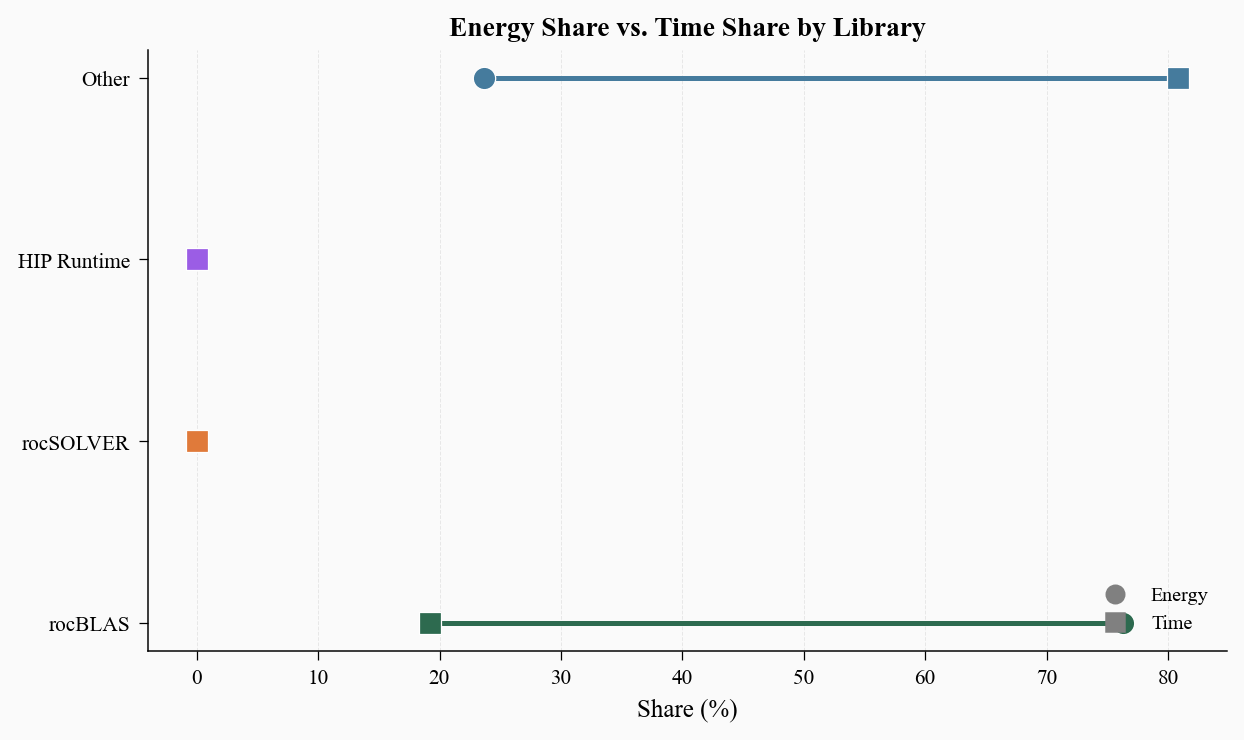

In [32]:
# -- Fig 8: Lollipop -- energy share vs time share by library --

e_by_lib = energy.groupby('Library')['Value'].sum()
e_frac = (e_by_lib / e_by_lib.sum() * 100)
t_by_lib = energy.groupby('Library')['Duration'].sum()
t_frac = (t_by_lib / t_by_lib.sum() * 100)

libs_plot = [c for c in LIB_ORDER if c in e_frac.index]

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor=BG)
ax.set_facecolor(BG)

y_pos = np.arange(len(libs_plot))
for i, lib in enumerate(libs_plot):
    ef = e_frac.get(lib, 0)
    tf = t_frac.get(lib, 0)
    lo, hi = min(ef, tf), max(ef, tf)
    ax.plot([lo, hi], [i, i], color=PALETTE[lib], linewidth=2, solid_capstyle='round', zorder=2)
    ax.scatter(ef, i, color=PALETTE[lib], s=80, zorder=3, marker='o', edgecolors='white', linewidth=0.5)
    ax.scatter(tf, i, color=PALETTE[lib], s=80, zorder=3, marker='s', edgecolors='white', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(libs_plot)
ax.set_xlabel('Share (%)')
ax.set_title('Energy Share vs. Time Share by Library', fontweight='bold')
ax.legend([Line2D([0],[0], marker='o', color='grey', ls='', ms=7),
           Line2D([0],[0], marker='s', color='grey', ls='', ms=7)],
          ['Energy', 'Time'], frameon=False, fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.25, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig8_energy_vs_time_share.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 9 — Power vs. Duration Density

Hexbin density plot showing where the mass of library calls falls in the
power-duration space. High-density regions indicate characteristic operating regimes.

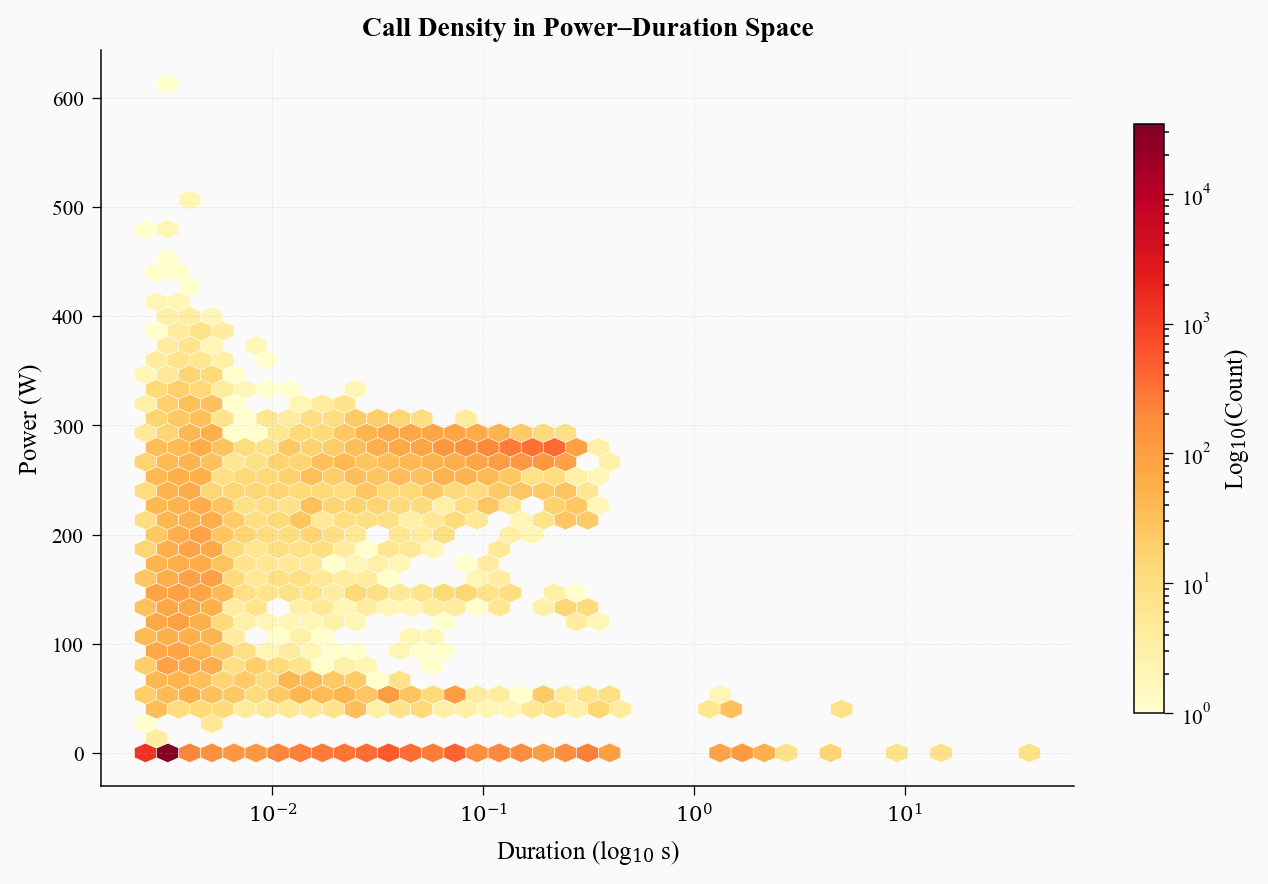

In [33]:
# -- Fig 9: Hexbin -- power vs duration --
plot_df = power_sig[(power_sig['Value'] > 0) & (power_sig['Duration'] >= 0.0025)].copy()

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=BG)
ax.set_facecolor(BG)

# Se añade bins='log' para que la densidad de llamadas use escala logarítmica
hb = ax.hexbin(np.log10(plot_df['Duration']),
               plot_df['Value'],
               gridsize=40, cmap='YlOrRd', mincnt=1,
               linewidths=0.2, edgecolors='white',
               bins='log') 

cb = fig.colorbar(hb, ax=ax, shrink=0.8, label='Log$_{10}$(Count)')

ax.set_xlabel('Duration (log$_{10}$ s)')
ax.set_ylabel('Power (W)')
ax.set_title('Call Density in Power–Duration Space', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'$10^{{{int(x)}}}$' if x == int(x) else f'$10^{{{x:.1f}}}$'))
ax.grid(alpha=0.2, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig9_power_duration_hexbin.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Figure 10 — Energy Variability Across Calls (CV)

Coefficient of variation (std/mean) of per-call energy for the most frequently called
functions. High CV indicates the function's energy cost varies significantly between invocations.

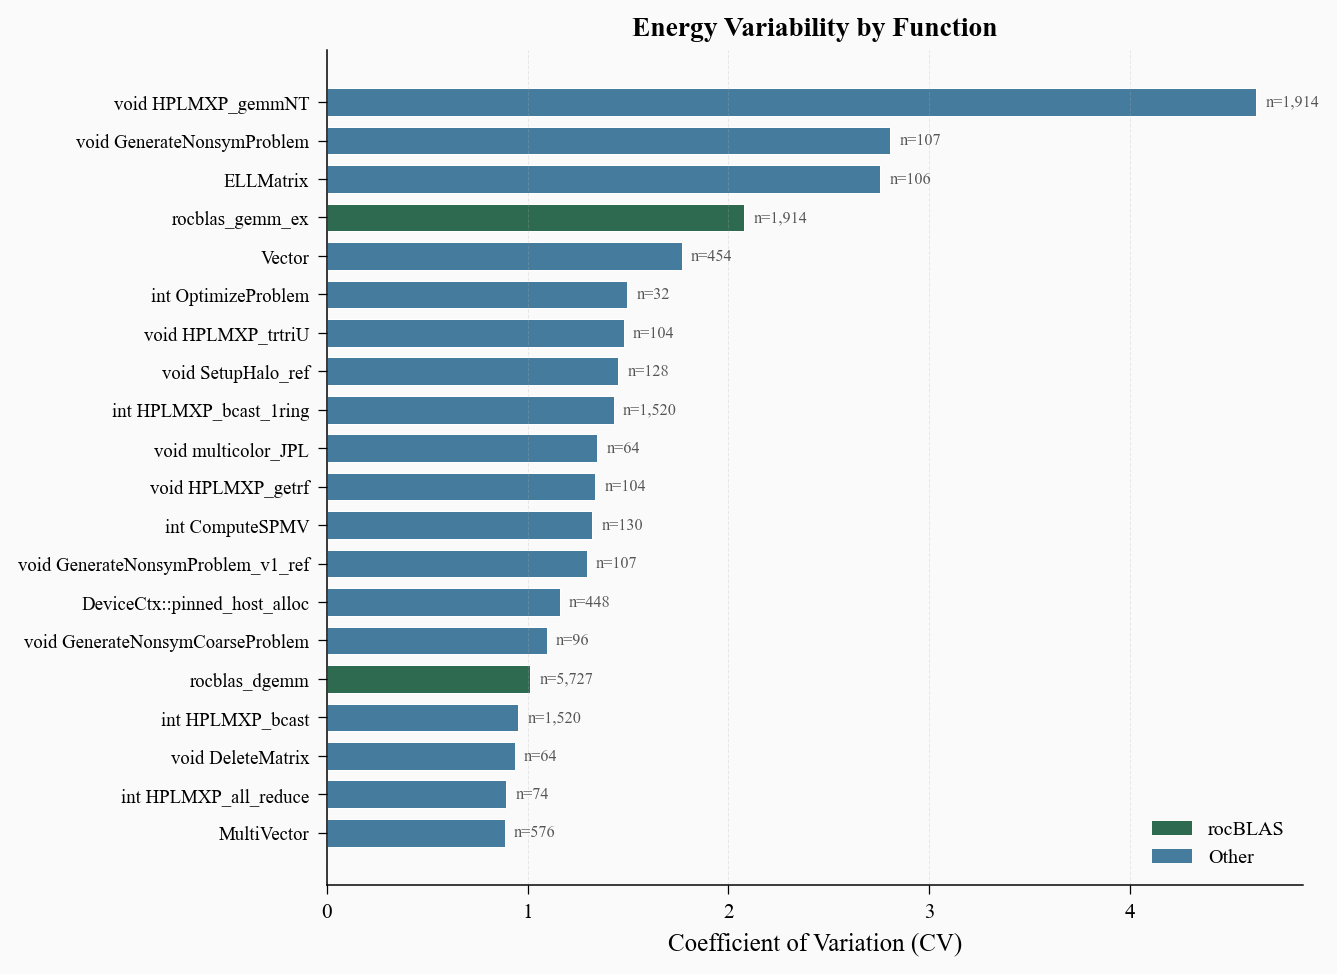

In [34]:
# -- Fig 10: CV of per-call energy --

cv_data = (energy_sig[energy_sig['Value'] > 0]
           .groupby(['ShortName', 'Library'])['Value']
           .agg(['mean', 'std', 'count']).reset_index())
cv_data = cv_data[cv_data['count'] >= 20].copy()
cv_data['cv'] = cv_data['std'] / cv_data['mean']
cv_data = cv_data.sort_values('cv', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=BG)
ax.set_facecolor(BG)

colors = [PALETTE.get(row['Library'], '#999999') for _, row in cv_data.iterrows()]
bars = ax.barh(range(len(cv_data)), cv_data['cv'].values,
               color=colors, edgecolor='white', linewidth=0.4, height=0.72)
ax.set_yticks(range(len(cv_data)))
ax.set_yticklabels(cv_data['ShortName'].values, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('Coefficient of Variation (CV)')
ax.set_title('Energy Variability by Function', fontweight='bold')

# Annotate call counts
for i, (_, row) in enumerate(cv_data.iterrows()):
    ax.text(row['cv'] + cv_data['cv'].max() * 0.01, i,
            f"n={row['count']:,}", va='center', fontsize=6.5, color='#555555')

handles = [mpatches.Patch(facecolor=PALETTE[c], label=c) for c in libs_present
           if c in cv_data['Library'].values]
ax.legend(handles=handles, frameon=False, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.25, linestyle='--')

fig.tight_layout()
fig.savefig('gen_fig10_cv.pdf', facecolor=BG, bbox_inches='tight')
plt.show()

## Summary Statistics

In [35]:
# -- Summary table --

summary = (energy_sig[energy_sig['Value'] > 0]
           .groupby('Library')
           .agg(
               total_energy_J=('Value', 'sum'),
               call_count=('Value', 'size'),
               mean_energy_J=('Value', 'mean'),
               median_energy_J=('Value', 'median'),
               std_energy_J=('Value', 'std'),
               mean_duration_s=('Duration', 'mean'),
               total_duration_s=('Duration', 'sum'),
           ).round(4))
summary['mean_power_W'] = (summary['total_energy_J'] / summary['total_duration_s']).round(2)
summary['energy_frac_%'] = (summary['total_energy_J'] / summary['total_energy_J'].sum() * 100).round(2)

print(summary.to_string())

             total_energy_J  call_count  mean_energy_J  median_energy_J  std_energy_J  mean_duration_s  total_duration_s  mean_power_W  energy_frac_%
Library                                                                                                                                              
HIP Runtime          0.2526           8         0.0316           0.0029        0.0807           0.0025            0.0204         12.38           0.00
Other             6601.7580      146075         0.0452           0.0003        1.9875           0.0125         1833.1765          3.60           4.52
rocBLAS         139263.8925       12192        11.4226           0.9538       18.6382           0.0443          540.0778        257.86          95.45
rocSOLVER           38.4135         107         0.3590           0.3613        0.1128           0.0035            0.3783        101.54           0.03
